# **Predicting Heart Disease using Machine Learning**


> This notebook looks into various Python-based machine learning and data science libraries in an attempt to build a machine learning model capable of predicting whether or not a person has a **heart disease** based on their **medical attributes**.

---

**We're going to take the following approch:**
1. Problem Defination
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

---

<div style="background:#ffffff; padding:12px; text-align:center;">
  <img src="./assets/images/6%20Step%20Machine%20Learning%20Modelling%20Framework.png" alt="6 Step Machine Learning Modelling Framework" style="max-width:100%; height:auto; width:auto;" />
</div>

<p align="center"><strong>6 Step Machine Learning Modelling Framework</strong></p>

![](./assets/images/step%20of%20the%20machine%20learning%20modelling%20process.png)

## **1. Problem Defination**

In a statement,
> Given clinical parameters about a patient, can we predict whether or not a person has heart disease?

## **2. Data**

- The [original data](./dataset/heart-disease.csv) came from the Cleavland data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease).

- There is also a [extented version](./dataset/heart_disease_uci.csv) available on [kaggle](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data). 

## **3. Evaluation**

> If we can reach 95% at predicting whether or not a person has a heart disease during the proof of concept. we'll pusue the project.

## **4. Features**

This is where you'll get the different information about each of the features in your data.

<div style="padding:12px 14px; border-left:4px solid #60a5fa; background:#111827; border-radius:10px; color:#e5e7eb;">
Think of this section as the <strong>data dictionary</strong>. Each row is one clue the model can use to learn patterns.
</div>

**Below is the Data Dictionary:**

| Feature  | Description | Example Values |
|:-----|:-----|:------|
| **age** | Age in years | 29, 45, 60 |
| **sex** | 1 = male; 0 = female | 0, 1 |
| **cp** | Chest pain type | 0: Typical angina, 1: Atypical angina, 2: Non-anginal pain, 3: Asymptomatic |
| **trestbps** | Resting blood pressure in mm Hg | 120, 140, 150 |
| **chol** | Serum cholesterol in mg/dl | 180, 220, 250 |
| **fbs** | Fasting blood sugar > 120 mg/dl (1 = true; 0 = false) | 0, 1 |
| **restecg** | Resting electrocardiographic results | 0: Nothing to note, 1: ST-T wave abnormality, 2: Left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved | 160, 180, 190 |
| **exang** | Exercise induced angina (1 = yes; 0 = no) | 0, 1 |
| **oldpeak** | ST depression induced by exercise relative to rest | 0.5, 1.0, 2.0 |
| **slope** | Slope of the peak exercise ST segment | 0: Upsloping, 1: Flat, 2: Downsloping |
| **ca** | Number of major vessels colored by fluoroscopy | 0, 1, 2, 3 |
| **thal** | Thalium stress result | 1: Normal, 3: Normal, 6: Fixed defect, 7: Reversible defect |
| **target** | Has disease or not (1 = yes; 0 = no) | 0, 1 |

---

<div style="padding:10px 12px; border-radius:10px; background:#0f172a; border:1px solid #334155; color:#cbd5e1;">
<strong style="color:#93c5fd;">Small tip:</strong> The model learns from patterns across all these features together, not from just one row by itself.
</div>

---
- **14 Features in total**
> **Note:** No personal identifiable information (PPI) can be found in the dataset.

## **Preparing the tools**

We're are going to use **Pandas**. **Numpy** and **Matplotlib** for data analysis and manipluation.

In [3]:
# import all the tools we need

# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# We want our plots to appear inside the notebook
%matplotlib inline  

# Models from Scikit-Learn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model Evaluations
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

## **Load Data**

In [4]:
df = pd.read_csv("./dataset/heart-disease.csv")
df.shape # (Rows, Columns)

(303, 14)

## **Data Explorartion or EDA (Exploratory Data Analysis)**

> The goal here is to find more about the data and become a subject matter expert on the dataset you are working with.

1. What question(s) are you trying to solve?
2. What kind of data do we have and how to treat different types?
3. What's missing from the data and how do you deal with it?
4. Where are the outliers and why should you care about them ?

<details>
  <summary><strong>Outlier</strong></summary>

An <strong>outlier</strong> is a data point that is much higher or lower than most other values.

Think of a classroom where most students are 18-22 years old, but one value says 85. That unusual value is an outlier.

Why it matters:
- It can be a real rare case (important signal).
- It can be a data entry or measurement error.
- It can affect model training and pull results in the wrong direction.

Simple check methods: boxplot, histogram, and IQR rule.
</details>

5. How can you add, change or remove features to get more out of your data?

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [6]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [7]:
# Let's find out how many each of the class are there
df["target"].value_counts()

target
1    165
0    138
Name: count, dtype: int64

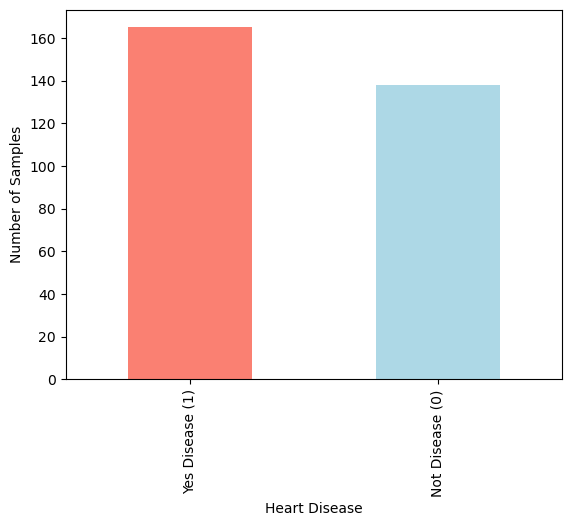

In [26]:
df['target'].value_counts().plot(kind="bar",
                                 color=["salmon", "lightblue"],
                                 xlabel="Heart Disease",
                                 ylabel="Number of Samples");
plt.xticks([0, 1], ["Yes Disease (1)", "Not Disease (0)"]);

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [28]:
# Are there any missing values?
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [31]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### **Heart Disease Frequency according to Sex**
- For sex:
  - 1 = male 
  - 0 = female

In [32]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

**So Males > Females**

In [33]:
# Comapare Target Column with Sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


**So like we get a intuation that:**
- **roughly `~75%` (72/96) of woman taking part in the test has Heart-Disease**

- **And roughly `~45%` (93/207) of man taking part in the test has Heart-Disease**

- **roughly `~54%` (165/303) of people taking part in the test has Heart-Disease**

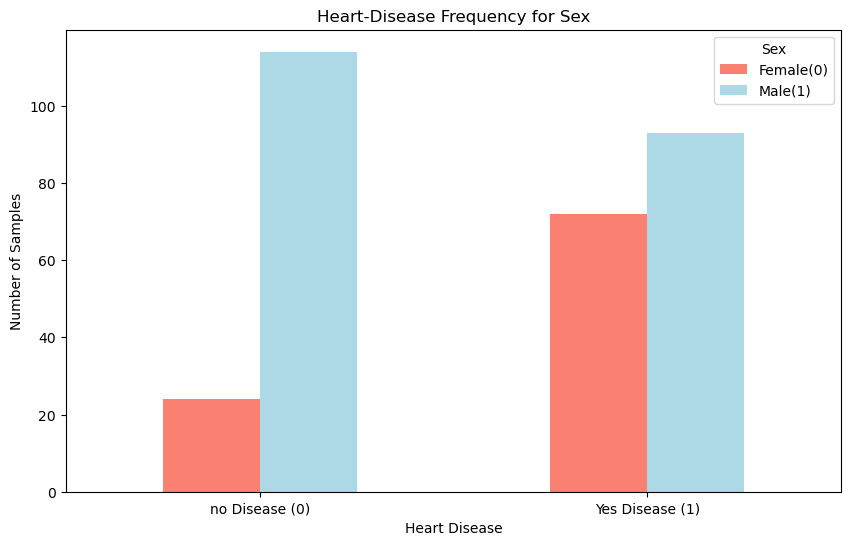

In [47]:
# Create a plot of cross-tab
pd.crosstab(df.target, df.sex).plot(kind="bar",
                                    figsize=(10,6),
                                    color=["salmon", "lightblue"],
                                    xlabel="Heart Disease",
                                    ylabel="Number of Samples")
plt.title("Heart-Disease Frequency for Sex")
plt.xticks([0,1], ["no Disease (0)", "Yes Disease (1)"], rotation=0)
plt.legend(["Female(0)", "Male(1)"], title="Sex");